# SPICE-posed synthetic lunar satellite imagery

Demo: pose a synthetic pinhole camera using the **real LRO spacecraft trajectory** (NAIF SPICE kernels) at the timestamp of a real LROC WAC image selected from a catalog-driven, illumination-filtered dataset search, render a synthetic 256x256 image from real Lunaserv WMS DEM/imagery with NASA's Ames Stereo Pipeline `sat_sim`, and compare it against the real WAC data. See `../docs/plan.md` for the full phase-by-phase approach and `../docs/data-sources.md` for the researched specifics referenced below.

This notebook drives the installed `trntest` package (see `../src/trntest/`) rather than duplicating its logic -- each cell is close to a one-line call into the package.

In [1]:
import dataclasses
import json

import trntest
from trntest import plotting

# isis_wac is unused while Phase 6 is temporarily disabled below -- re-add this import when re-enabling it.

session = trntest.Session()
session.config.output_dir.mkdir(parents=True, exist_ok=True)

## Phase 2: catalog-driven image selection + SPICE-derived camera pose

`session.select_dataset()` queries the real LROC catalog (via the PDS Geosciences Node ODE REST API) for a multi-orbit window with favorable illumination geometry and good WAC data availability, and returns a throttled, illumination-filtered image list (see `trntest.dataset`/`trntest.illumination`). `session.generate_dataset(images, limit=1)` then poses a pinhole camera for the first selected image, using LRO's real position/orientation (from NAIF SPICE kernels, in the `MOON_ME` frame) at that instant, and runs the rest of the pipeline (DEM/ortho fetch, `sat_sim` render) in one call.

In [2]:
images = session.select_dataset(max_search_days=7)
images

select_dataset: 81 images across 12 orbits (2019-11-01 01:13:09.847000+00:00 to 2019-11-02 00:40:33.176000+00:00); per-orbit counts: {46625: 7, 46626: 7, 46627: 7, 46628: 7, 46629: 7, 46630: 7, 46631: 7, 46632: 7, 46633: 7, 46634: 7, 46635: 7, 46636: 7}


,product_id,edr_volume,edr_subdir,edr_doy,edr_product,cdr_volume,cdr_subdir,cdr_doy,cdr_product,orbit_number,start_time,stop_time,start_frame,center_frame_index,n_frames_for_square_crop,sun_elevation_deg,incidence_angle_deg,center_lat_deg,center_lon_deg
0,M1327210646CE,LROLRC_0041B,ESM4,2019305,M1327210646CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:22:59.051000+00:00,2019-11-01 01:29:01.864000+00:00,93.5,129.0,71,41.844544,48.16,38.5020,169.5177
1,M1327211014CE,LROLRC_0041B,ESM4,2019305,M1327211014CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:29:06.171000+00:00,2019-11-01 01:34:22.421000+00:00,75.0,110.0,70,28.650836,61.35,55.4504,171.8937
2,M1327211334CE,LROLRC_0041B,ESM4,2019305,M1327211334CE,LROLRC_1041B,ESM4,2019305,M1327210646CC,46625,2019-11-01 01:34:26.729000+00:00,2019-11-01 01:39:25.323000+00:00,69.5,105.0,71,15.823285,74.18,70.7112,177.0545
3,M1327215525CE,LROLRC_0041B,ESM4,2019305,M1327215525CE,LROLRC_1041B,ESM4,2019305,M1327215170CC,46625,2019-11-01 02:44:17.189000+00:00,2019-11-01 02:52:24.126000+00:00,259.5,294.0,69,19.388089,70.61,-67.5433,156.7774
4,M1327216016CE,LROLRC_0041B,ESM4,2019305,M1327216016CE,LROLRC_1041B,ESM4,2019305,M1327215525CC,46625,2019-11-01 02:52:28.428000+00:00,2019-11-01 02:57:51.396000+00:00,126.5,159.0,65,36.649340,53.35,-46.4285,161.8946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,M1327288708CE,LROLRC_0041B,ESM4,2019305,M1327288708CE,LROLRC_1041B,ESM4,2019305,M1327288003CC,46636,2019-11-01 23:04:00.714000+00:00,2019-11-01 23:10:23.683000+00:00,94.0,129.0,70,15.866035,74.14,70.9007,165.3437
77,M1327292971CE,LROLRC_0041B,ESM4,2019306,M1327292971CE,LROLRC_1041B,ESM4,2019306,M1327292540CC,46636,2019-11-02 00:15:03.961000+00:00,2019-11-02 00:22:22.711000+00:00,227.0,260.0,66,20.268884,69.73,-66.7155,145.0769
78,M1327293414CE,LROLRC_0041B,ESM4,2019306,M1327293414CE,LROLRC_1041B,ESM4,2019306,M1327292971CC,46636,2019-11-02 00:22:27.016000+00:00,2019-11-02 00:27:43.454000+00:00,132.0,166.0,68,36.628572,53.37,-46.9781,149.8148
79,M1327293735CE,LROLRC_0041B,ESM4,2019306,M1327293735CE,LROLRC_1041B,ESM4,2019306,M1327292971CC,46636,2019-11-02 00:27:47.758000+00:00,2019-11-02 00:36:07.133000+00:00,199.0,235.0,72,51.669499,38.33,-25.9000,151.8709


In [3]:
results = session.generate_dataset(images, limit=1)
result = results[0]

camera = result.camera
frame_timing = result.frame_timing
session = trntest.Session(config=result.config)

print(json.dumps(dataclasses.asdict(camera), indent=2, default=str))

ROI bbox (lon/lat deg): (np.float64(164.16309422035133), np.float64(34.107740474798476), np.float64(175.17467183095962), np.float64(42.715420961471395)), size 2616x2610 px (~100.0 m/px)


generate_dataset: 1 succeeded, 0 failed
{
  "et": 625843629.6404576,
  "center_frame_index": 129.0,
  "camera_center_moon_me_m": [
    -1436043.1493582418,
    265174.67205154215,
    1154372.7412624918
  ],
  "r_cam_to_me": [
    [
      0.2278412438332859,
      0.5782552858908102,
      0.7833959356212143
    ],
    [
      0.9714237853177388,
      -0.18995357201418805,
      -0.14231468581283818
    ],
    [
      0.066514636941483,
      0.7934346002150322,
      -0.6050101968183303
    ]
  ],
  "boresight_rotation_k": 3,
  "slant_range_km": 124.10635562882112,
  "off_nadir_deg": 1.1043402272340213,
  "focal_length_px": 215.57656937953163,
  "footprint_lonlat_deg": {
    "center": [
      169.52577312637044,
      38.40441758271966
    ],
    "top_left": [
      172.29597342226285,
      35.72168056604965
    ],
    "top_right": [
      166.22776502234038,
      36.09806632352299
    ],
    "bottom_left": [
      173.11000102897057,
      40.660864509771415
    ],
    "bottom_rig

Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [4]:
print(f"Slant range to surface: {camera.slant_range_km:.2f} km")
print(f"Off-nadir angle: {camera.off_nadir_deg:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

Slant range to surface: 124.11 km
Off-nadir angle: 1.10 deg
Ground footprint center (lon, lat): (np.float64(169.52577312637044), np.float64(38.40441758271966))


## Phase 3: DEM + ortho from Lunaserv WMS

Fetch `luna_wac_normalized_reflectance` (visible mosaic, despeckled and blended with a real-sun-lit hillshade -- see `docs/data-sources.md`) and `luna_wac_dtm_numeric_meters_absolute` (GLD100 DEM, converted from planetocentric radius to elevation) for the footprint above, through the local cache.

In [5]:
lunaserv_result = result.lunaserv_result
print(json.dumps(dataclasses.asdict(lunaserv_result), indent=2, default=str))

{
  "ortho": "/workspace/output/dataset/M1327210646CE/ortho_shaded.tif",
  "dem": "/workspace/output/dataset/M1327210646CE/dem_filled-tile-0.tif",
  "bbox": [
    164.16309422035133,
    34.107740474798476,
    175.17467183095962,
    42.715420961471395
  ],
  "width": 2616,
  "height": 2610
}


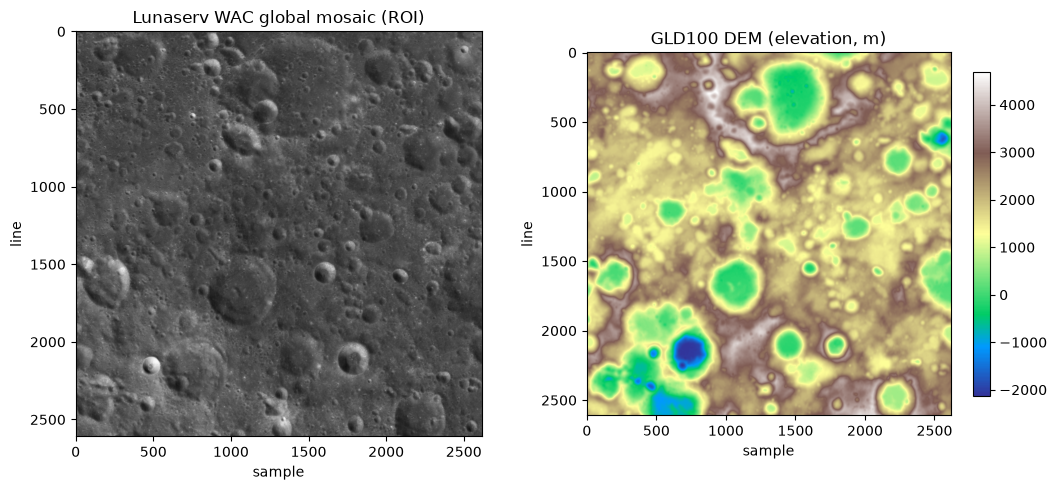

In [6]:
plotting.plot_dem_ortho(lunaserv_result);

### Camera footprint over the DEM

Plot the SPICE-derived camera's ground footprint (corners + center) on top of the ortho mosaic, to visually confirm the pose lands where expected.

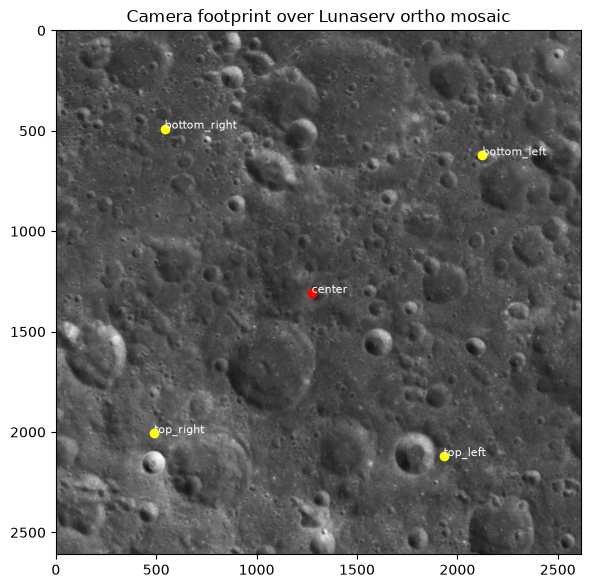

In [7]:
plotting.plot_camera_footprint(lunaserv_result, camera);

## Phase 4: render with `sat_sim` + the real camera pose

`session.generate_dataset()` already called `run_sat_sim(camera, lunaserv_result)` above, which:
1. Calls `sat_sim --camera-list` with the Phase 2 `.tsai` camera against the Phase 3 DEM/ortho, producing the synthetic 256x256 image.
2. Calls ASP's `cam_gen` to convert that exact camera to a CSM Frame model-state JSON (the "ISD" sidecar) -- `--save-as-csm` is a no-op in `--camera-list` mode, see `docs/data-sources.md`.

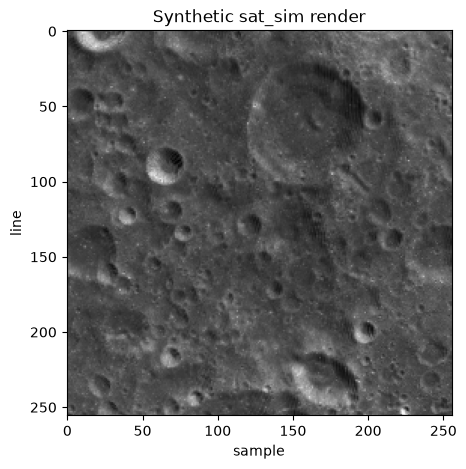

In [8]:
render_result = result.render_result
plotting.plot_synthetic_render(render_result.rendered_tif);

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string" convention; skip it before parsing.

In [9]:
model_name, csm_state = trntest.read_csm_state(render_result.csm_json)

print('Model name:', model_name)
for key in ['m_focalLength', 'm_nLines', 'm_nSamples', 'm_ccdCenter', 'm_currentParameterValue']:
    print(f'{key}: {csm_state[key]}')

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 215.57656937953163
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [128.0, 128.0]
m_currentParameterValue: [-1436043.1494426618, 265174.672067679, 1154372.7412770423, 0.7111267490398353, 0.5447970678794134, 0.29879011503513647, 0.3289671241740103]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame) and the last 4 are the orientation quaternion -- matching the `C`/`R` we computed from SPICE in Phase 2.

## Phase 5: a recognizable image from the real WAC CDR, with SPICE-derived tie points

WAC is a push-frame camera: each 78-line frame multiplexes 7 filters (2 UV @ 4 TDI lines + 5 VIS @ 14 TDI lines), and per the official LROC SIS, the CDR "will require further processing to separate framelets into their respective bands ... in order to be viewed as a standard image." `session.fetch_vis_mosaic(camera)` does that: it pulls one VIS filter's 14-line block (an offset guaranteed pure-VIS regardless of WAC's current yaw-dependent band ordering -- see the module docstring) from many consecutive frames and stacks them, which is exactly how WAC's push-frame design builds continuous coverage. The frame count is computed (not a fixed guess) so the crop covers the same real ground distance as the synthetic camera's FOV -- see `docs/plan.md`.

`select_dataset()` already filtered out unilluminated products (sun elevation >= 10 deg at each candidate's midpoint-anchored image center, computed via SPICE's `ilumin` -- see `trntest.dataset.anchor_start_frame_for_centered_crop`), so the selected image is guaranteed well-lit without hand-tuning a start frame the way earlier iterations of this demo did. The synthetic camera's pose epoch is that crop's own temporal midpoint (`camera.center_frame_index`), so both images are centered on the same ground point.

`session.compute_tie_points()` adds explicit, geometry-derived tie points: it finds the real ground area both images cover (each image's own footprint, an inscribed axis-aligned lon/lat box per image, intersected), picks 5 points in a die's "5"/X pattern (4 corners + center, 10% margin from the shared area's edges), and projects each into both images' pixel coordinates using their real camera models (closed-form pinhole for the synthetic image; a small root-find over frame index for the real crop, which mixes many real poses). Both panels are plotted in real km (not raw pixel index) so the non-square-pixel CDR crop and the square-pixel synthetic image display at the same true scale.

In [10]:
tie_point_results = session.compute_tie_points(camera, frame_timing)
for name, r in tie_point_results.items():
    print(f"{name:12s} lonlat={r['lonlat']}  synthetic_px={r['synthetic_px']}  crop_px={r['crop_px']}")

top_left     lonlat=(np.float64(167.44198132899075), np.float64(40.09566014667658))  synthetic_px=(np.float64(217.11147549436163), np.float64(209.07602425167738))  crop_px=(np.float64(105.14621187953449), 173.81332397460938)
top_right    lonlat=(np.float64(171.82153826154303), np.float64(40.09566014667658))  synthetic_px=(np.float64(44.87277066296262), np.float64(223.45419452068637))  crop_px=(np.float64(584.7093363569438), 117.96905517578125)
center       lonlat=(np.float64(169.63175979526687), np.float64(38.392726926850244))  synthetic_px=(np.float64(123.5886822593166), np.float64(127.74614745075357))  crop_px=(np.float64(364.12941590648245), 490.97198486328125)
bottom_left  lonlat=(np.float64(167.44198132899075), np.float64(36.68979370702391))  synthetic_px=(np.float64(208.0338851053661), np.float64(32.21231827686303))  crop_px=(np.float64(130.68940862011462), 857.1429824829102)
bottom_right lonlat=(np.float64(171.82153826154303), np.float64(36.68979370702391))  synthetic_px=(np.flo

### North-up rotation (display only)

The sensor model's own pixel axes (Part A) are a **fixed, hardware-motivated** choice -- not something that should vary by pass -- but *which way is north* in that fixed convention depends on this specific pass (ascending vs. descending, plus any yaw state), so it's computed here purely for display. `trntest.orientation` picks, for each image independently, the multiple of 90 degrees (no mirroring) whose on-screen "up" is closest to true north, and this is applied only to the plotted arrays and tie-point marker positions below -- the `.tsai`, the CSM/ISD JSON, and `session.compute_tie_points()`'s own returned pixel values are untouched.

Since both images already share the same axis convention (Part A), we expect -- and confirm below -- that they need the *same* rotation here.

In [11]:
rotations = session.compute_display_rotations(camera, frame_timing)
print(f"synthetic: rotate {rotations.k_synthetic*90} deg for north-up (residual {rotations.dev_synthetic_deg:.1f} deg from true north)")
print(f"real crop: rotate {rotations.k_crop*90} deg for north-up (residual {rotations.dev_crop_deg:.1f} deg from true north)")

synthetic: rotate 180 deg for north-up (residual 4.8 deg from true north)
real crop: rotate 0 deg for north-up (residual 4.5 deg from true north)


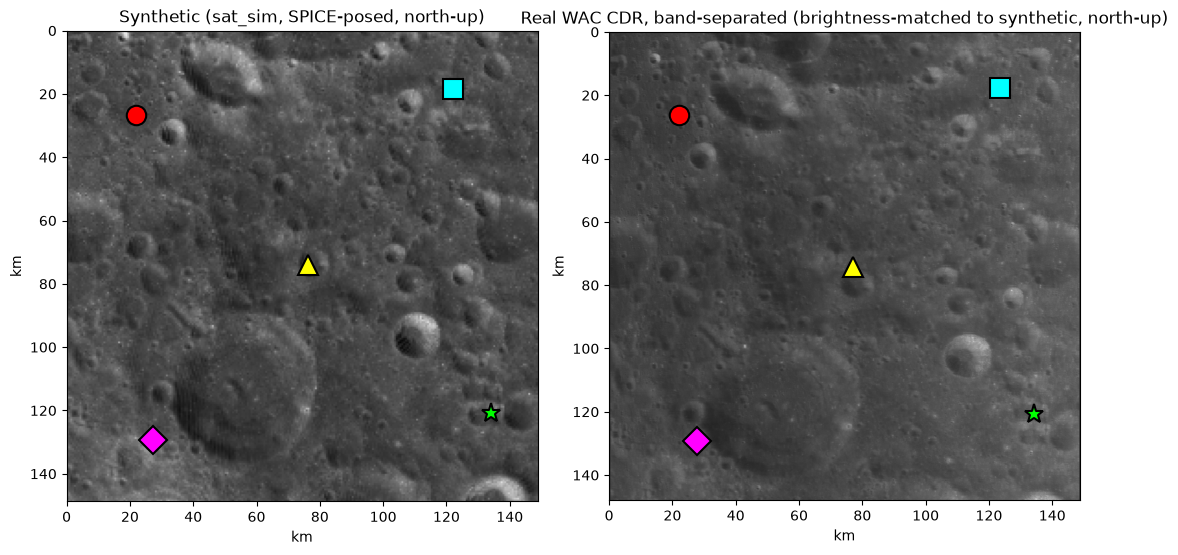

In [12]:
vis_mosaic = session.fetch_vis_mosaic(camera)
plotting.plot_comparison(camera, tie_point_results, vis_mosaic, rotations, render_result.rendered_tif);

## Phase 6: compare against a genuine ISIS/CSM-processed WAC image

Phase 5's comparison uses `wac.py`'s manual framelet-stacking (hand-derived byte offsets into the CDR). `isis_wac.run_pipeline()` instead steps the same product's real EDR through ISIS3's own pipeline (`lrowac2isis` -> `spiceinit web=yes` -> `lrowaccal` -> `framestitch`) -- a genuine camera-model-based alternative, not yet reprojected onto the DEM (`mapproject`, still an open item -- see `docs/plan.md`). `flip` is derived from `camera.reverse_crop_along_track`, the same real SPICE-derived per-pass yaw-state signal used throughout this notebook -- not a fixed per-product constant.

`isis_wac.crop_window_for_camera()` picks the same real-footprint frame range (`camera.center_frame_index` +/- half of `camera.n_frames_for_square_crop`) that `wac.fetch_vis_mosaic` above already uses, so both comparisons cover the same real ground area -- by construction, not by search. `plotting.plot_isis_comparison()` reuses the same north-up rotation and real-km extent scaling (Phase 5, above) that `plot_comparison` already applies -- the ISIS cube shares `wac.py`'s exact pixel-axis convention, so the same `rotations.k_crop` and physical-km scaling apply here too, not just to `wac.py`'s own crop. Phase 5's `tie_point_results` are reused directly, not recomputed -- `tie_points.py`'s crop-pixel projection was never CSM/ISD-based to begin with (pure SPICE frame-index geometry), and its coordinate origin/scaling exactly matches `crop_window_for_camera`'s, so the same points land correctly here with no new geometry code.

In [13]:
# Temporarily disabled: the external ISIS SPICE web service (`spiceinit web=yes`) is currently
# failing ("SPICE server returned incompatible SPICE data"), unrelated to this repo's own code --
# confirmed non-transient (same failure on repeated runs). Re-enable once that service recovers.
# stitched = isis_wac.run_pipeline(camera, frame_timing, session.config)

In [14]:
# plotting.plot_isis_comparison(camera, tie_point_results, render_result.rendered_tif, stitched.cub_path, isis_wac.crop_window_for_camera(camera), rotations);

## Summary

- Selected a real, illuminated LROC WAC EDR from a catalog-driven, multi-orbit dataset search (`trntest.dataset.select_dataset`, via the PDS ODE REST API and SPICE-derived orbit/illumination geometry), then computed LRO's true position/orientation at that image's timestamp directly in the Moon's `MOON_ME` frame via `spiceypy`, using a minimal, selectively-cached SPICE kernel set (see `docs/caching.md`).
- Built a `.tsai` Pinhole camera from that pose and rendered a synthetic 256x256 image with ASP's `sat_sim`, fed by real DEM/imagery pulled live from Lunaserv WMS for the camera's own computed ground footprint.
- Produced a CSM/"ISD" JSON sidecar for the rendered camera (`cam_gen`), and cross-validated the whole pose pipeline: `cam_gen` independently recovered the same sub-spacecraft geodetic position from the `.tsai`'s raw ECEF pose that the original SPICE computation produced.
- Compared against a properly band-separated crop of the real WAC CDR from the same part of the swath -- which required both de-interleaving WAC's push-frame format and discovering (then avoiding) a long shadowed stretch at the start of the original single-demo product (now handled generally by `select_dataset`'s illumination filtering).
- Also compared against the same real footprint processed through ISIS3's own pipeline (`isis_wac.run_pipeline`) instead of `wac.py`'s manual framelet-stacking -- a genuine camera-model-based alternative, not yet reprojected onto the DEM (see `docs/plan.md`'s open items for the still-unresolved framelet-boundary striping question this is investigating).